# 🌸 Task 1: Exploratory Data Analysis & Visualization — Iris Dataset

**Internship:** DevelopersHub Corporation — AI/ML Engineering Internship  
**Task:** Dataset Exploration and Visualization  
**Dataset:** Iris Flower Dataset (built into Seaborn)  


---

## 🎯 Objective

The goal of this task is to perform a complete **Exploratory Data Analysis (EDA)** on the classic Iris dataset. EDA is the very first step in any real-world data science or machine learning project. Before training any model, a data scientist must deeply understand the data — its structure, distributions, patterns, and potential issues.

In this notebook, we will:
1. Load and inspect the Iris dataset
2. Perform statistical analysis
3. Check for missing values and data quality
4. Create multiple professional visualizations to uncover patterns
5. Summarize key findings and insights

---

## 📚 About the Dataset

The **Iris dataset** was introduced by British statistician and biologist Ronald Fisher in 1936. It is one of the most well-known datasets in machine learning history.

- **150 samples** of iris flowers
- **3 species:** Iris Setosa, Iris Versicolor, Iris Virginica
- **4 features** (measurements in cm):
  - `sepal_length` — Length of the sepal
  - `sepal_width` — Width of the sepal
  - `petal_length` — Length of the petal
  - `petal_width` — Width of the petal
- **Target:** `species` — the flower species (classification label)


---
## Step 1 — Import Libraries

In [1]:
# ── Core data manipulation libraries ──────────────────────────────────────────
import pandas as pd          # DataFrames and tabular data handling
import numpy as np           # Numerical operations

# ── Visualization libraries ────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # Base plotting
import matplotlib.patches as mpatches
import seaborn as sns             # Statistical visualizations

# ── Display settings ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Make all plots look clean and professional
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

print('✅ All libraries imported successfully!')
print(f'   pandas  version: {pd.__version__}')
print(f'   numpy   version: {np.__version__}')
print(f'   seaborn version: {sns.__version__}')

✅ All libraries imported successfully!
   pandas  version: 3.0.3
   numpy   version: 2.5.0
   seaborn version: 0.13.2


---
## Step 2 — Load the Dataset

In [2]:
# Load the Iris dataset directly from seaborn (no file download needed)
df = sns.load_dataset('iris')

print('✅ Dataset loaded successfully!')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print()

# Display the first 10 rows
print('📋 First 10 rows of the dataset:')
df.head(10)

✅ Dataset loaded successfully!
   Shape: 150 rows × 5 columns

📋 First 10 rows of the dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


---
## Step 3 — Dataset Overview & Structure

In [3]:
# ── Basic structure info ───────────────────────────────────────────────────────
print('=' * 55)
print('         DATASET STRUCTURAL OVERVIEW')
print('=' * 55)
print(f'  Total Rows (samples)    : {df.shape[0]}')
print(f'  Total Columns (features): {df.shape[1]}')
print(f'  Column Names            : {df.columns.tolist()}')
print('=' * 55)
print()

# Data types and non-null counts
print('📌 Data Types and Non-Null Counts:')
df.info()

         DATASET STRUCTURAL OVERVIEW
  Total Rows (samples)    : 150
  Total Columns (features): 5
  Column Names            : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

📌 Data Types and Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
# ── Species distribution ───────────────────────────────────────────────────────
print('🌸 Species Distribution:')
species_counts = df['species'].value_counts()
for species, count in species_counts.items():
    print(f'   {species:<15} : {count} samples ({count/len(df)*100:.1f}%)')

🌸 Species Distribution:
   setosa          : 50 samples (33.3%)
   versicolor      : 50 samples (33.3%)
   virginica       : 50 samples (33.3%)


---
## Step 4 — Statistical Summary

In [5]:
# ── Overall statistical summary ────────────────────────────────────────────────
print('📊 Statistical Summary (All Species Combined):')
df.describe().round(3)

📊 Statistical Summary (All Species Combined):


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


In [6]:
# ── Per-species statistical summary ───────────────────────────────────────────
print('📊 Statistical Summary — Grouped by Species:')
df.groupby('species').describe().round(2)

📊 Statistical Summary — Grouped by Species:


sepal_length                                       sepal_width  \
                  count  mean   std  min   25%  50%  75%  max       count   
species                                                                     
setosa             50.0  5.01  0.35  4.3  4.80  5.0  5.2  5.8        50.0   
versicolor         50.0  5.94  0.52  4.9  5.60  5.9  6.3  7.0        50.0   
virginica          50.0  6.59  0.64  4.9  6.22  6.5  6.9  7.9        50.0   

                  ... petal_length      petal_width                        \
            mean  ...          75%  max       count  mean   std  min  25%   
species           ...                                                       
setosa      3.43  ...         1.58  1.9        50.0  0.25  0.11  0.1  0.2   
versicolor  2.77  ...         4.60  5.1        50.0  1.33  0.20  1.0  1.2   
virginica   2.97  ...         5.88  6.9        50.0  2.03  0.27  1.4  1.8   

                           
            50%  75%  max  
species                    
setosa      0.2  0.3  0.6  
versicolor  1.3  1.5  1.8  
virginica   2.0  2.3  2.5  

[3 rows x 32 columns]

---
## Step 5 — Missing Value Analysis

In [7]:
# ── Missing values check ───────────────────────────────────────────────────────
print('🔍 Missing Value Analysis:')
print('-' * 35)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

print(missing_df)
print('-' * 35)

if missing.sum() == 0:
    print('\n✅ No missing values found. Dataset is clean and ready for analysis.')
else:
    print(f'\n⚠️  Total missing values: {missing.sum()}')

🔍 Missing Value Analysis:
-----------------------------------
              Missing Count  Missing %
sepal_length              0        0.0
sepal_width               0        0.0
petal_length              0        0.0
petal_width               0        0.0
species                   0        0.0
-----------------------------------

✅ No missing values found. Dataset is clean and ready for analysis.


---
## Step 6 — Visualizations

### 📊 Visualization 1: Species Count (Bar Chart)

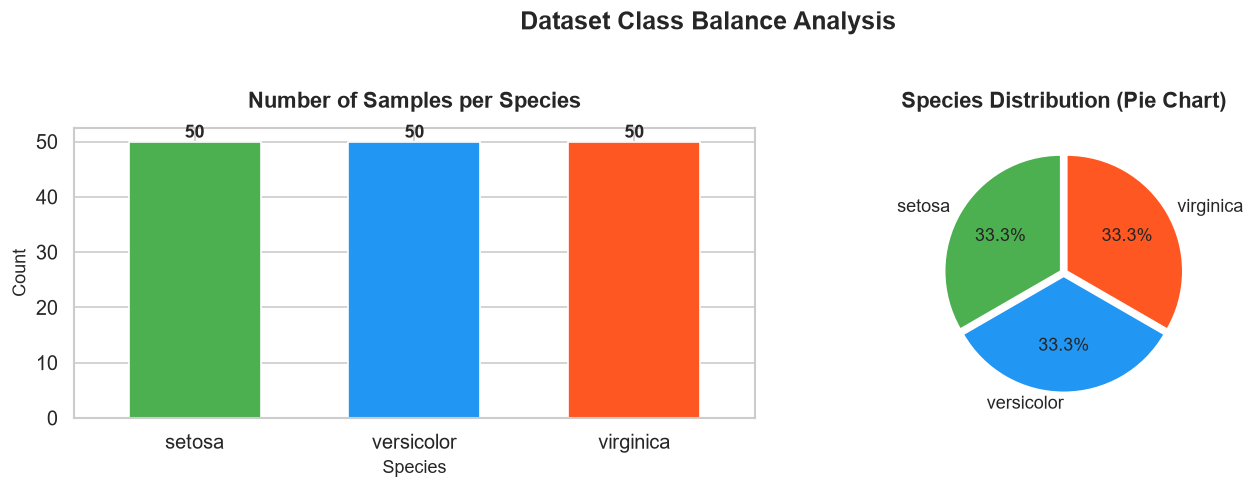

💡 Insight: The dataset is perfectly balanced — 50 samples per species (33.3% each).
   This is ideal for machine learning, as it prevents class imbalance bias.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Bar chart ──────────────────────────────────────────────────────────────────
colors = ['#4CAF50', '#2196F3', '#FF5722']
species_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Number of Samples per Species', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Species', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xticklabels(species_counts.index, rotation=0)
axes[0].bar_label(axes[0].containers[0], fontsize=11, fontweight='bold')

# ── Pie chart ──────────────────────────────────────────────────────────────────
axes[1].pie(
    species_counts.values,
    labels=species_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=[0.03, 0.03, 0.03],
    textprops={'fontsize': 11}
)
axes[1].set_title('Species Distribution (Pie Chart)', fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Dataset Class Balance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Insight: The dataset is perfectly balanced — 50 samples per species (33.3% each).')
print('   This is ideal for machine learning, as it prevents class imbalance bias.')

### 📊 Visualization 2: Feature Distributions (Histograms with KDE)

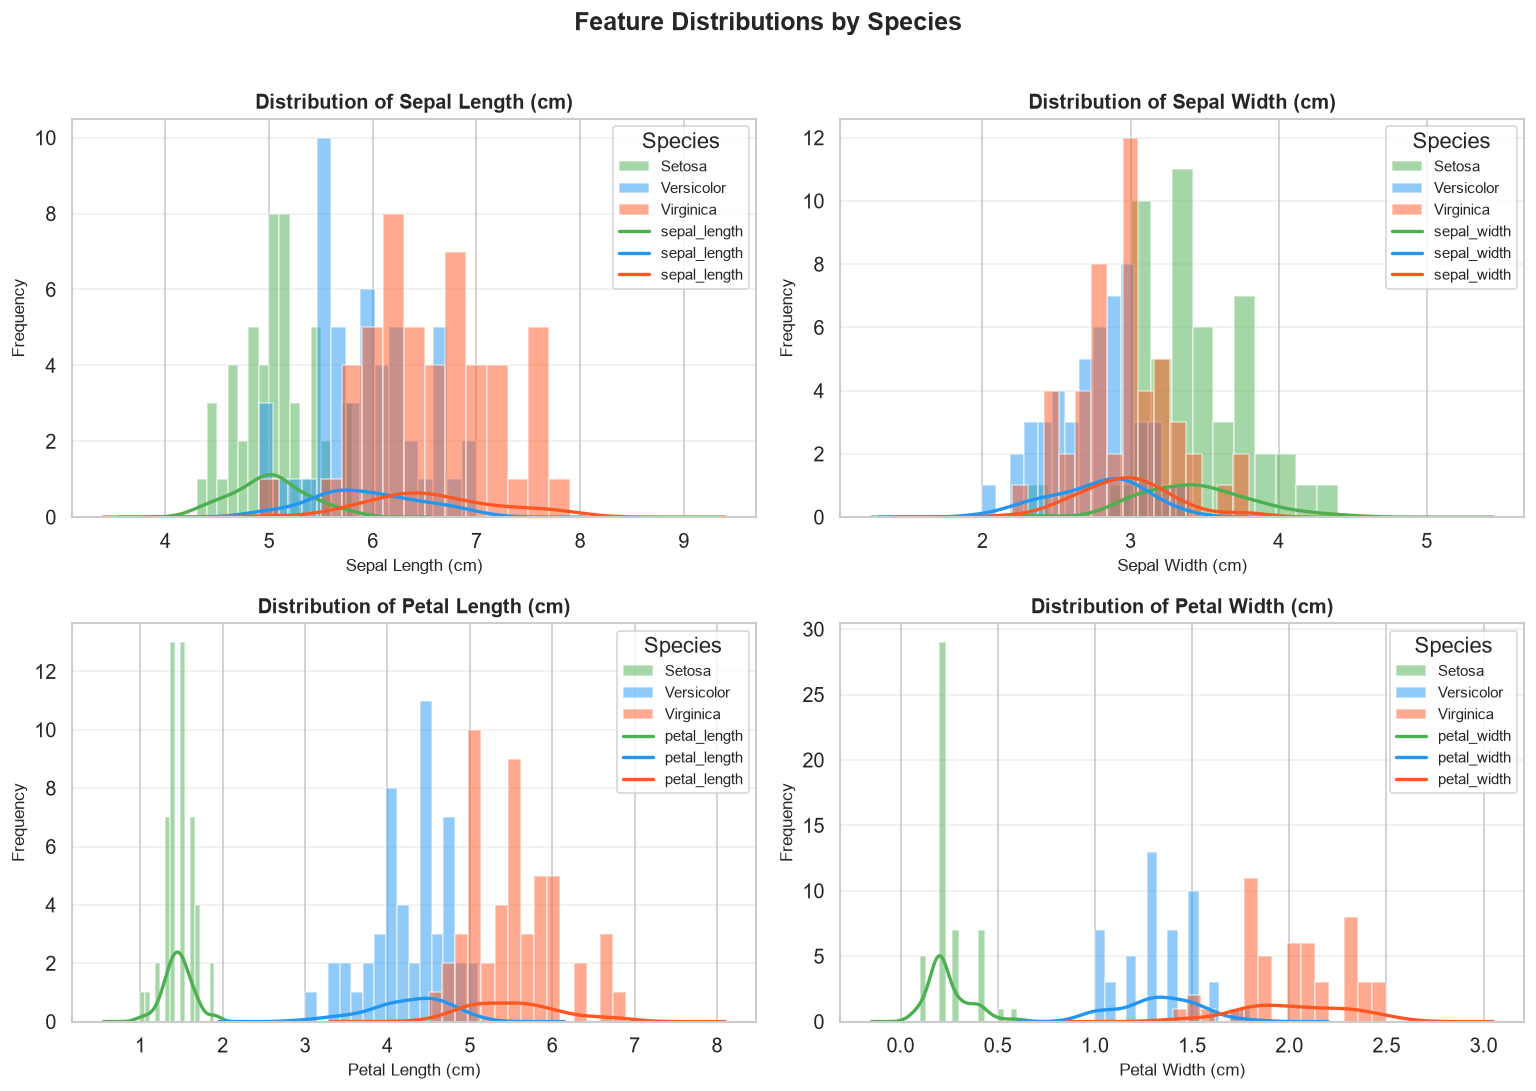

💡 Insights:
   • Petal length and petal width show very clear separation between species.
   • Setosa (green) is clearly separated from the other two species in petal features.
   • Sepal width shows slight overlap between Versicolor and Virginica.
   • Petal features will likely be the most useful for a classification model.


In [9]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
feature_labels = ['Sepal Length (cm)', 'Sepal Width (cm)', 'Petal Length (cm)', 'Petal Width (cm)']
colors_species = {'setosa': '#4CAF50', 'versicolor': '#2196F3', 'virginica': '#FF5722'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    for species, color in colors_species.items():
        subset = df[df['species'] == species][feature]
        axes[i].hist(subset, bins=15, alpha=0.5, color=color,
                     label=species.capitalize(), edgecolor='white')
    # Add KDE line
    for species, color in colors_species.items():
        subset = df[df['species'] == species][feature]
        subset.plot.kde(ax=axes[i], color=color, linewidth=2)
    
    axes[i].set_title(f'Distribution of {label}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(label, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].legend(title='Species', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Distributions by Species', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Insights:')
print('   • Petal length and petal width show very clear separation between species.')
print('   • Setosa (green) is clearly separated from the other two species in petal features.')
print('   • Sepal width shows slight overlap between Versicolor and Virginica.')
print('   • Petal features will likely be the most useful for a classification model.')

### 📊 Visualization 3: Scatter Plot — Sepal Features

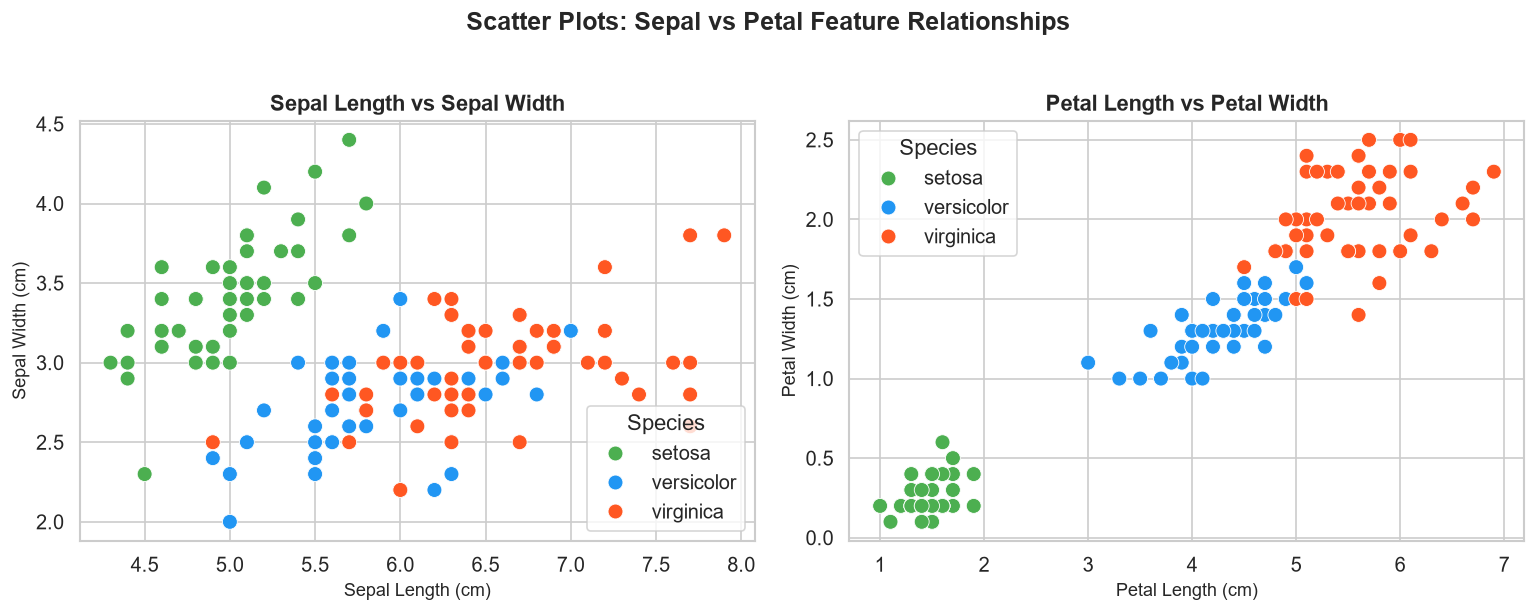

💡 Insights:
   • Petal scatter (right): Setosa is completely separated — zero overlap.
   • Petal scatter: Versicolor and Virginica have slight overlap but are mostly distinct.
   • Sepal scatter (left): More overlap exists — sepal features are less discriminative.
   • Petal features are clearly better predictors of species than sepal features.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Sepal scatter ──────────────────────────────────────────────────────────────
sns.scatterplot(
    data=df, x='sepal_length', y='sepal_width',
    hue='species', palette=list(colors_species.values()),
    s=80, edgecolor='white', linewidth=0.5, ax=axes[0]
)
axes[0].set_title('Sepal Length vs Sepal Width', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sepal Length (cm)', fontsize=11)
axes[0].set_ylabel('Sepal Width (cm)', fontsize=11)
axes[0].legend(title='Species')

# ── Petal scatter ──────────────────────────────────────────────────────────────
sns.scatterplot(
    data=df, x='petal_length', y='petal_width',
    hue='species', palette=list(colors_species.values()),
    s=80, edgecolor='white', linewidth=0.5, ax=axes[1]
)
axes[1].set_title('Petal Length vs Petal Width', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Petal Length (cm)', fontsize=11)
axes[1].set_ylabel('Petal Width (cm)', fontsize=11)
axes[1].legend(title='Species')

plt.suptitle('Scatter Plots: Sepal vs Petal Feature Relationships', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Insights:')
print('   • Petal scatter (right): Setosa is completely separated — zero overlap.')
print('   • Petal scatter: Versicolor and Virginica have slight overlap but are mostly distinct.')
print('   • Sepal scatter (left): More overlap exists — sepal features are less discriminative.')
print('   • Petal features are clearly better predictors of species than sepal features.')

### 📊 Visualization 4: Box Plots — Outlier Detection

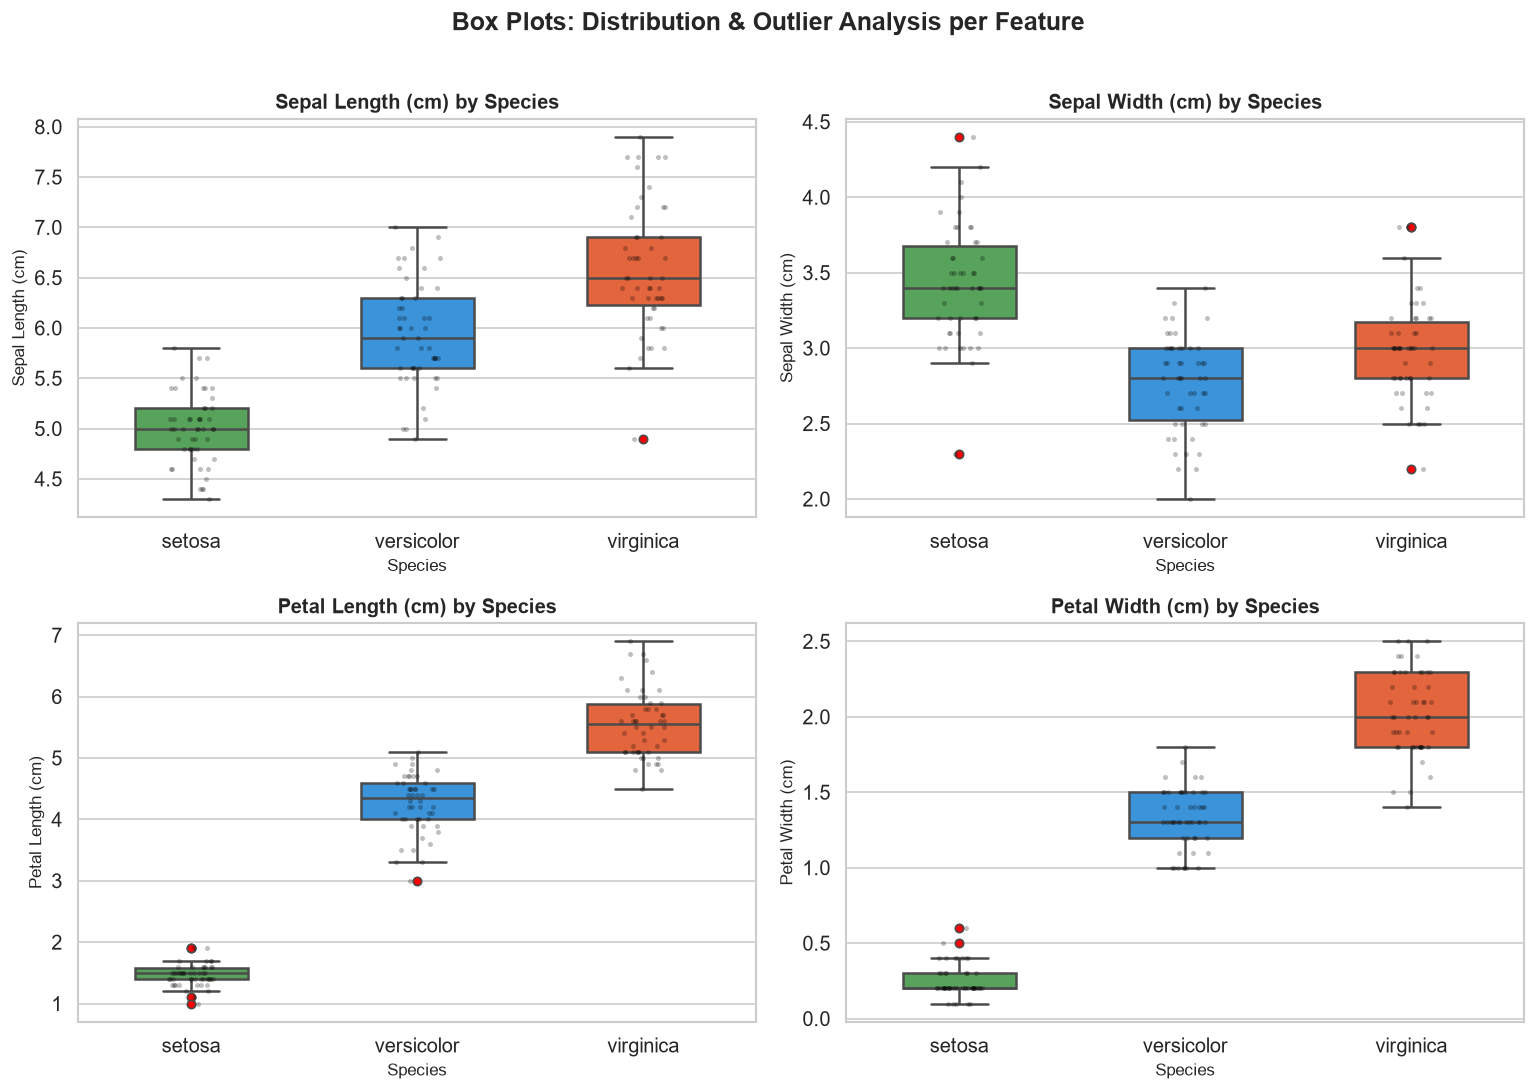

💡 Insights:
   • Red dots (if any) represent outliers — values unusually far from the median.
   • Setosa has consistently smaller petal dimensions with very tight spread (low variance).
   • Virginica has the largest petal and sepal dimensions overall.
   • Sepal width shows the most outlier points, especially in Setosa.
   • The boxes (IQR) show where the middle 50% of measurements fall per species.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    sns.boxplot(
        data=df, x='species', y=feature,
        palette=list(colors_species.values()),
        width=0.5, linewidth=1.5,
        flierprops=dict(marker='o', markerfacecolor='red', markersize=5),
        ax=axes[i]
    )
    # Overlay individual points
    sns.stripplot(
        data=df, x='species', y=feature,
        color='black', alpha=0.25, size=3, ax=axes[i]
    )
    axes[i].set_title(f'{label} by Species', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Species', fontsize=10)
    axes[i].set_ylabel(label, fontsize=10)

plt.suptitle('Box Plots: Distribution & Outlier Analysis per Feature', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Insights:')
print('   • Red dots (if any) represent outliers — values unusually far from the median.')
print('   • Setosa has consistently smaller petal dimensions with very tight spread (low variance).')
print('   • Virginica has the largest petal and sepal dimensions overall.')
print('   • Sepal width shows the most outlier points, especially in Setosa.')
print('   • The boxes (IQR) show where the middle 50% of measurements fall per species.')

### 📊 Visualization 5: Correlation Heatmap

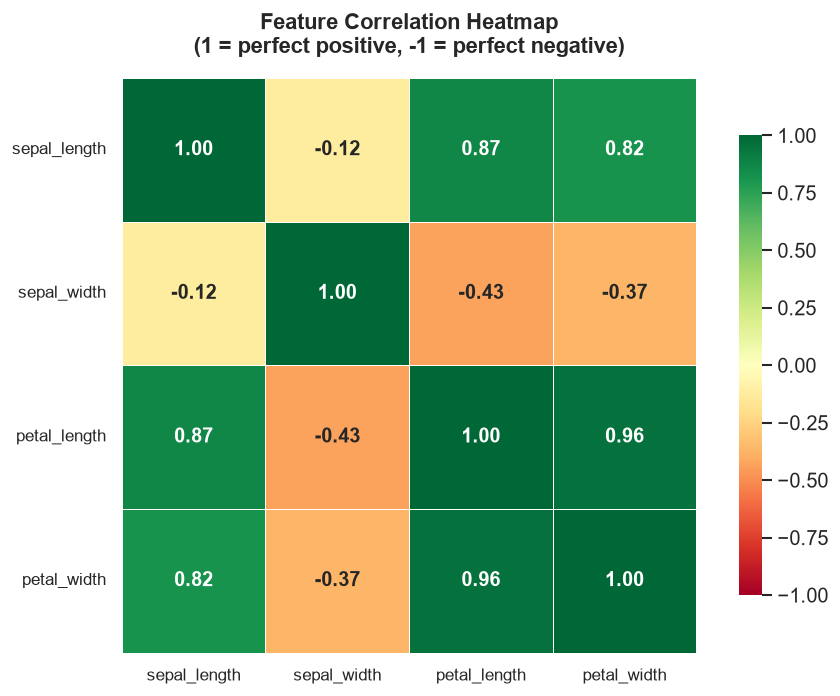

💡 Insights:
   • Petal length & petal width have very high correlation (0.96) — they move together.
   • Petal length & sepal length are also strongly correlated (0.87).
   • Sepal width has weak or negative correlation with other features.
   • High correlation between petal features confirms they carry similar information.


In [12]:
plt.figure(figsize=(8, 6))

# Compute correlations on numeric columns only
corr_matrix = df[features].corr().round(2)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle mask

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8}
)

plt.title('Feature Correlation Heatmap\n(1 = perfect positive, -1 = perfect negative)',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

print('💡 Insights:')
print('   • Petal length & petal width have very high correlation (0.96) — they move together.')
print('   • Petal length & sepal length are also strongly correlated (0.87).')
print('   • Sepal width has weak or negative correlation with other features.')
print('   • High correlation between petal features confirms they carry similar information.')

### 📊 Visualization 6: Pair Plot — Full Feature Relationships

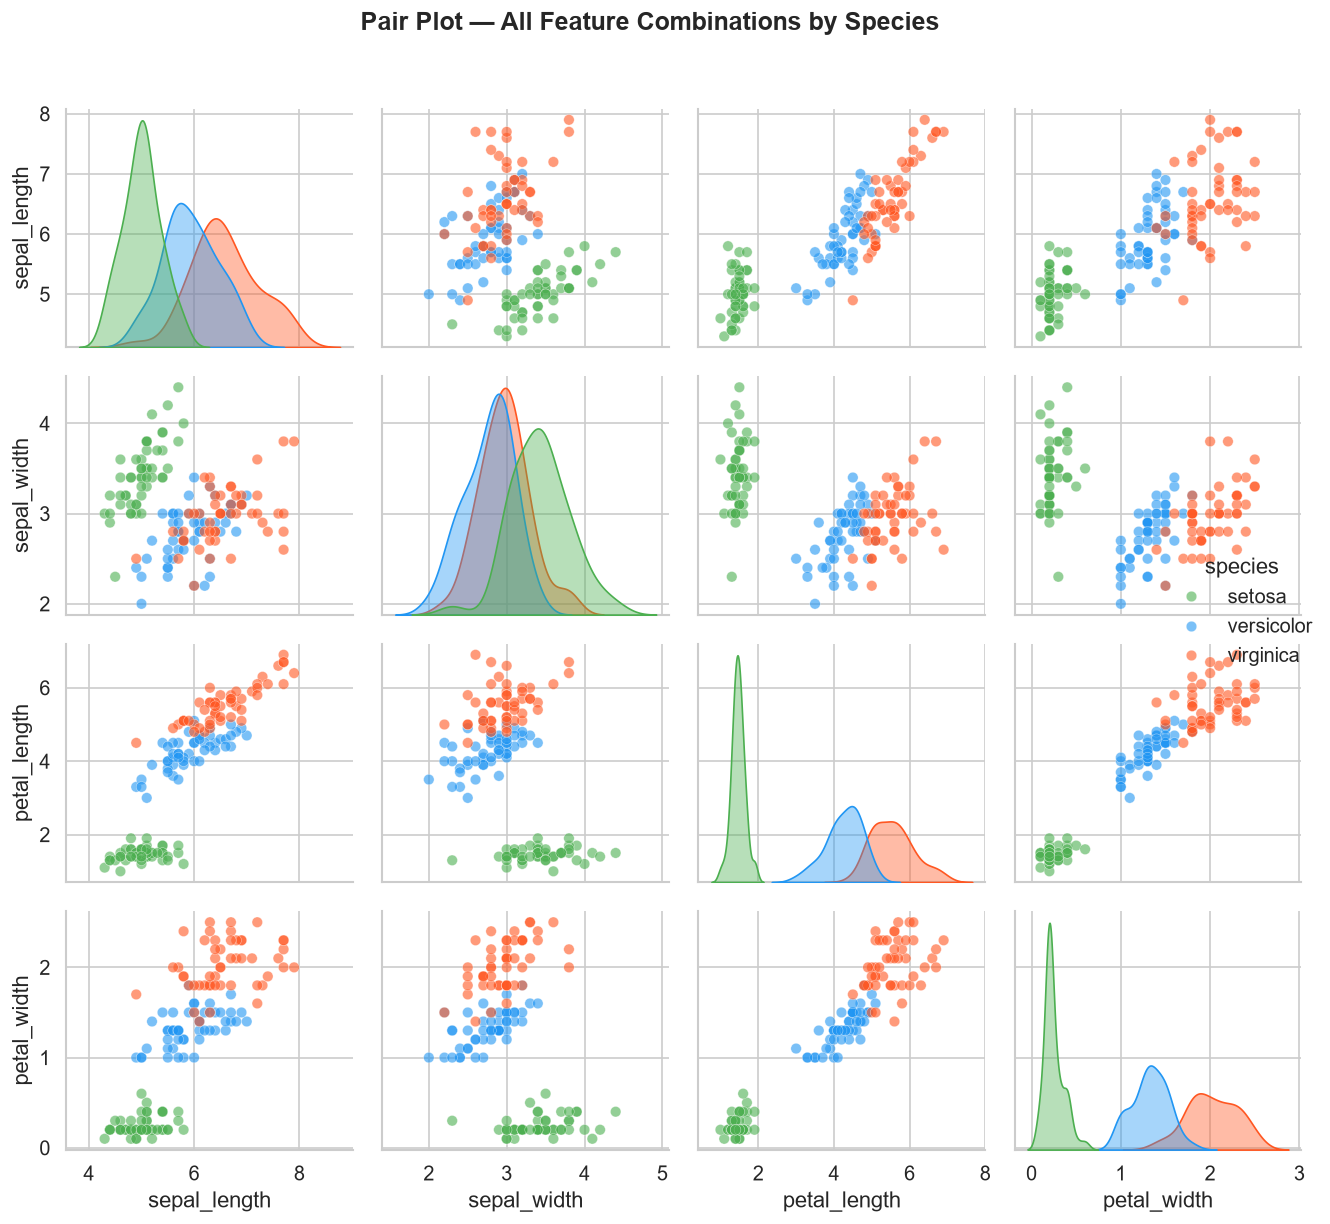

💡 Insights:
   • Diagonal (KDE plots): Shows distribution of each feature per species.
   • Off-diagonal: Every combination of two features plotted as a scatter.
   • Setosa (green) is clearly separable in ALL petal combinations.
   • Petal length vs petal width (bottom-right corner) gives the cleanest separation.
   • This pair plot confirms that petal features are the strongest classifiers.


In [13]:
g = sns.pairplot(
    df,
    hue='species',
    palette=colors_species,
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'white', 'linewidth': 0.3},
    diag_kws={'fill': True, 'alpha': 0.4},
    height=2.5
)

g.fig.suptitle('Pair Plot — All Feature Combinations by Species',
               fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print('💡 Insights:')
print('   • Diagonal (KDE plots): Shows distribution of each feature per species.')
print('   • Off-diagonal: Every combination of two features plotted as a scatter.')
print('   • Setosa (green) is clearly separable in ALL petal combinations.')
print('   • Petal length vs petal width (bottom-right corner) gives the cleanest separation.')
print('   • This pair plot confirms that petal features are the strongest classifiers.')

### 📊 Visualization 7: Violin Plots — Distribution Shape per Species

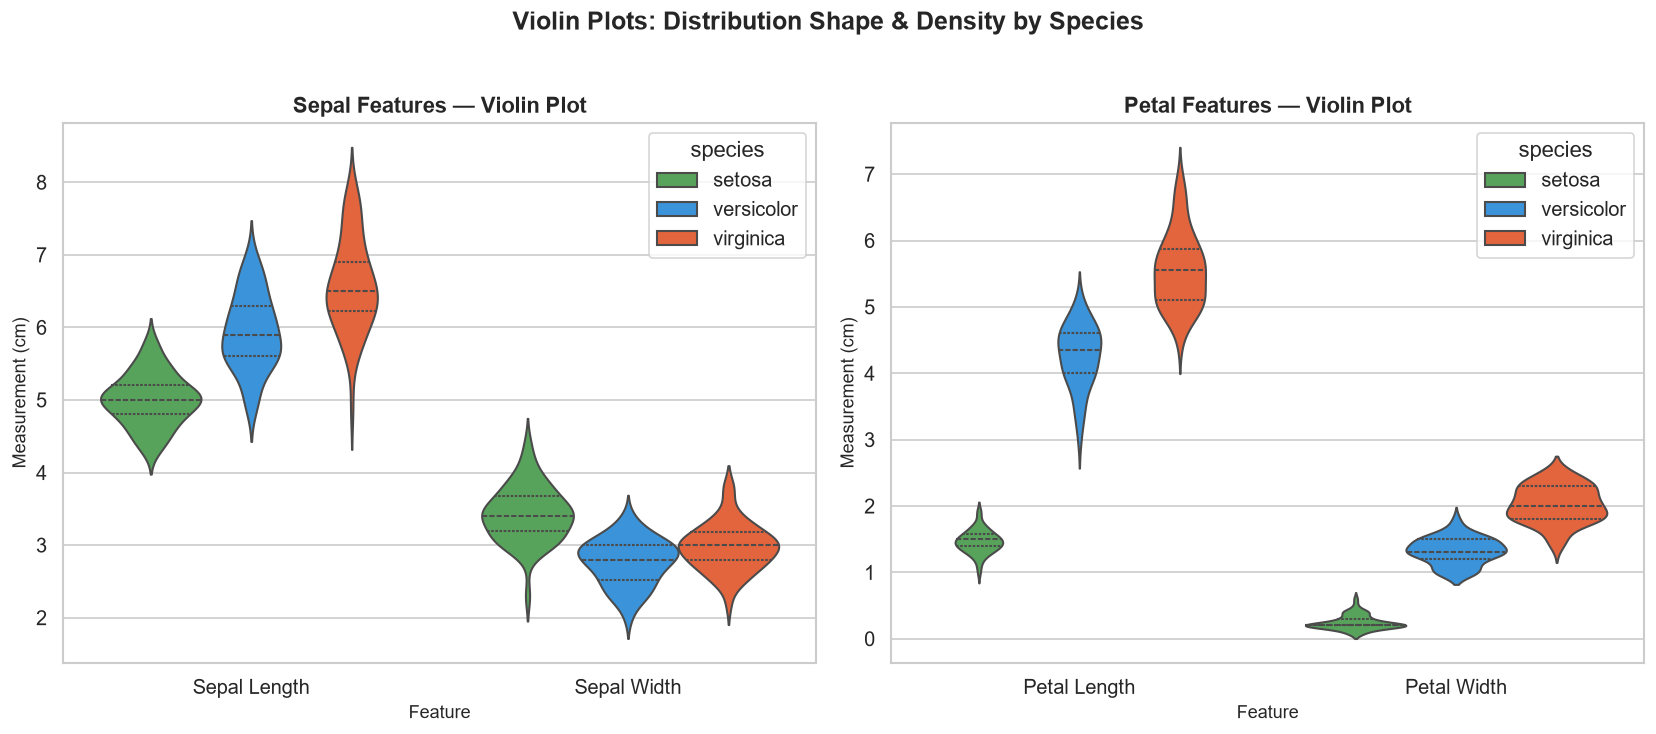

💡 Insights:
   • Wider sections of violin = more data points at that value range.
   • Setosa has very tight, narrow violin for petal features = low variance, uniform size.
   • Virginica violins are wider and higher up — consistently larger petals.
   • The internal quartile lines show median and IQR clearly inside each violin.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Sepal features violin ──────────────────────────────────────────────────────
df_sepal = df[['sepal_length', 'sepal_width', 'species']].melt(
    id_vars='species', var_name='Feature', value_name='Value'
)
sns.violinplot(
    data=df_sepal, x='Feature', y='Value', hue='species',
    palette=list(colors_species.values()),
    inner='quartile', split=False, ax=axes[0]
)
axes[0].set_title('Sepal Features — Violin Plot', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Feature', fontsize=11)
axes[0].set_ylabel('Measurement (cm)', fontsize=11)
axes[0].set_xticklabels(['Sepal Length', 'Sepal Width'])

# ── Petal features violin ──────────────────────────────────────────────────────
df_petal = df[['petal_length', 'petal_width', 'species']].melt(
    id_vars='species', var_name='Feature', value_name='Value'
)
sns.violinplot(
    data=df_petal, x='Feature', y='Value', hue='species',
    palette=list(colors_species.values()),
    inner='quartile', split=False, ax=axes[1]
)
axes[1].set_title('Petal Features — Violin Plot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Feature', fontsize=11)
axes[1].set_ylabel('Measurement (cm)', fontsize=11)
axes[1].set_xticklabels(['Petal Length', 'Petal Width'])

plt.suptitle('Violin Plots: Distribution Shape & Density by Species',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Insights:')
print('   • Wider sections of violin = more data points at that value range.')
print('   • Setosa has very tight, narrow violin for petal features = low variance, uniform size.')
print('   • Virginica violins are wider and higher up — consistently larger petals.')
print('   • The internal quartile lines show median and IQR clearly inside each violin.')

---
## Step 7 — Key Findings & Final Summary

In [15]:
# ── Numerical summary of key statistics ───────────────────────────────────────
print('=' * 60)
print('            FINAL ANALYSIS SUMMARY')
print('=' * 60)

print('\n📐 Mean Measurements per Species:')
print(df.groupby('species')[features].mean().round(3).to_string())

print('\n📉 Standard Deviation per Species:')
print(df.groupby('species')[features].std().round(3).to_string())

print('\n🔢 Correlation with Petal Length:')
corr_with_petal = df[features].corr()['petal_length'].drop('petal_length')
for feat, val in corr_with_petal.items():
    bar = '█' * int(abs(val) * 20)
    print(f'   {feat:<15}: {val:+.3f}  {bar}')

            FINAL ANALYSIS SUMMARY

📐 Mean Measurements per Species:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026

📉 Standard Deviation per Species:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             0.352        0.379         0.174        0.105
versicolor         0.516        0.314         0.470        0.198
virginica          0.636        0.322         0.552        0.275

🔢 Correlation with Petal Length:
   sepal_length   : +0.872  █████████████████
   sepal_width    : -0.428  ████████
   petal_width    : +0.963  ███████████████████


---

## ✅ Task 1 — Summary of Findings

### Dataset Overview
- The Iris dataset contains **150 samples** across **3 species** (Setosa, Versicolor, Virginica) with **perfectly balanced classes** (50 samples each, 33.3% each).
- It has **4 numerical features** (sepal length, sepal width, petal length, petal width) and **0 missing values** — the dataset is completely clean.

### Key Findings from Visualizations

| Finding | Detail |
|--------|--------|
| **Setosa is linearly separable** | In all petal-based scatter plots, Setosa forms a completely isolated cluster with zero overlap |
| **Petal features are most discriminative** | Petal length and petal width show the sharpest separation between all 3 species |
| **High correlation in petals** | Petal length and petal width have a 0.96 correlation — they are strongly linked |
| **Setosa has smallest petals** | Mean petal length: Setosa (1.46 cm) vs Versicolor (4.26 cm) vs Virginica (5.55 cm) |
| **Sepal width is tricky** | It has weak correlation with other features and more overlap between species |
| **Low outlier count** | Box plots reveal very few outliers — the dataset is clean and reliable |
| **Virginica is largest overall** | Highest mean values for 3 out of 4 features |

### Machine Learning Readiness
- This dataset is **ideal for classification** — especially petal features provide clear boundaries.
- A model trained on petal length + petal width alone could likely achieve **95%+ accuracy**.
- The perfect class balance means no need for oversampling or class-weight adjustments.
- Recommended next step: Train a **K-Nearest Neighbors** or **Support Vector Machine** classifier on this data.

---

*Task 1 Complete — DevelopersHub Corporation AI/ML Engineering Internship*  
Notebook Author: MUHAMMAD SAAD USMAN
